<p style="font-size:300%; background-color:#ffe6f0; color:#0044cc; text-align:center; line-height:80px; margin:0; padding:0;">
  <b>Sistemas Expertos</b>
</p>

<p style="font-size:240%; background-color:#ffe6f0; color:#cc0000; text-align:center; line-height:60px; margin:0; padding:0;">
  <b>Técnicas de Inteligencia Artificial</b>
</p>

<p style="font-size:200%; text-align:center; line-height:40px; margin:0;">
  <br><b>Prof. Flavio Prieto</b>
</p>

<p style="font-size:160%; text-align:center; line-height:25px; margin:0;">
  email: <a href="mailto:faprietoo@unal.edu.co">faprietoo@unal.edu.co</a>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  <br><b>DEPARTAMENTO DE INGENIERÍA MECÁNICA Y MECATRÓNICA</b>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  Facultad de Ingeniería
</p>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  Universidad Nacional de Colombia – Sede Bogotá
</p>

<div style="text-align:center; margin-top:20px; margin-bottom:10px;">
  <img src="Fig/Escudo_UN.png" alt="Escudo UNAL" width="90" style="border:none;">
</div>


# **EJEMPLO:** Motor de Inferencia Simple Usando 'Experta'

> Inatalar la biblioteca **experta**

In [1]:
#!pip install experta

In [2]:
from experta import *

## Se define una clase llamada `Sintoma` que hereda de `Fact`.

- Un `Fact` representa un hecho o dato conocido dentro del sistema experto.

- La clase `Sintoma` modela la información correspondiente a cada síntoma del paciente.


In [3]:
# Definición de los hechos
class Sintoma(Fact):
    """Hecho: representa un síntoma"""
    pass

## Se define la clase principal del motor experto, que hereda de `KnowledgeEngine`.

- Esta clase contiene las reglas de inferencia y controla el proceso de razonamiento.

- Se define una regla con `@Rule(Sintoma(fiebre=True)`.
    - La regla se activa cuando se cumplen todas las condiciones: que existan hechos que indiquen fiebre, dolor de cabeza y congestión.
    - Si la regla se cumple, se ejecuta la función `posible_gripe` que imprime el diagnóstico de gripe.

- Otra regla detecta la posible alergia si hay estornudos y congestión, pero no fiebre.

- Hay una regla para el caso en que el paciente no presenta ninguno de los síntomas mencionados.

In [4]:
# Motor de inferencia
class DiagnosticoSalud(KnowledgeEngine):

    def __init__(self):
        super().__init__()
        self.diagnostico_hecho = False  # Flag para saber si alguna regla se disparó
    
    @Rule(Sintoma(fiebre=True), Sintoma(dolor_cabeza=True), Sintoma(congestion=True))
    def posible_gripe(self):
        print("Diagnóstico: Puede tener GRIPE.")
        self.diagnostico_hecho = True

    @Rule(Sintoma(estornudos=True), Sintoma(congestion=True), Sintoma(fiebre=False))
    def posible_alergia(self):
        print("Diagnóstico: Puede tener ALERGIA.")
        self.diagnostico_hecho = True

    @Rule(Sintoma(fiebre=False), Sintoma(dolor_cabeza=False), Sintoma(congestion=False), Sintoma(estornudos=False))
    def sin_sintomas(self):
        print("Diagnóstico: No presenta síntomas relevantes.")
        self.diagnostico_hecho = True

## Se define una función llamada `diagnosticar` que recibe cuatro parámetros:

    - `fiebre`
    - `dolor_cabeza`
    - `congestion`
    - `estornudos`

- Cada parámetro es un valor booleano (`True` o `False`) que indica si el paciente presenta o no ese síntoma.


In [5]:
def diagnosticar(fiebre, dolor_cabeza, congestion, estornudos):
    engine = DiagnosticoSalud()   # Se crea una instancia del motor experto
                                  # Esta instancia es el objeto que contiene las reglas de diagnóstico
                                  # y gestiona el proceso de inferencia.
    
    engine.reset()   # Se reinicia el motor experto para borrar cualquier estado previo o hechos antiguos.
                     # Esto prepara el motor para una nueva ronda de inferencia limpia y sin datos residuales.

# A continuación se insertan en la base de conocimiento los hechos actuales, es decir, los síntomas que presenta el paciente.
# Cada llamada a declare() agrega un hecho Sintoma con el valor que se pasó como argumento a la función.
    
    engine.declare(Sintoma(fiebre=fiebre))
    engine.declare(Sintoma(dolor_cabeza=dolor_cabeza))
    engine.declare(Sintoma(congestion=congestion))
    engine.declare(Sintoma(estornudos=estornudos))
    
    engine.run()   # Se ejecuta el motor de inferencia para evaluar las reglas basadas en los hechos declarados.
                   # Si alguna regla coincide con los síntomas, se ejecuta la acción correspondiente
                   # (por ejemplo, imprimir el diagnóstico).

    if not engine.diagnostico_hecho:
        print("No se pudo determinar diagnóstico con los síntomas proporcionados.")

In [6]:
diagnosticar(fiebre=True, dolor_cabeza=True, congestion=True, estornudos=False)

Diagnóstico: Puede tener GRIPE.


In [7]:
diagnosticar(fiebre=True, dolor_cabeza=True, congestion=True)

TypeError: diagnosticar() missing 1 required positional argument: 'estornudos'

Para llamar a la función `diagnosticar` pasando solo algunos parámetros con valores específicos, como `congestion=True` y `estornudos=False`, es necesario que la función tenga valores por defecto en los demás parámetros. Esto evita errores por falta de argumentos.

Por ejemplo, la función podría definirse así:


In [8]:
def diagnosticar(fiebre=False, dolor_cabeza=False, congestion=False, estornudos=False):
    engine = DiagnosticoSalud()
    engine.reset()
    engine.declare(Sintoma(fiebre=fiebre))
    engine.declare(Sintoma(dolor_cabeza=dolor_cabeza))
    engine.declare(Sintoma(congestion=congestion))
    engine.declare(Sintoma(estornudos=estornudos))
    engine.run()
    if not engine.diagnostico_hecho:
        print("No se pudo determinar diagnóstico con los síntomas proporcionados.")

In [9]:
diagnosticar(fiebre=True, dolor_cabeza=True, congestion=True)

Diagnóstico: Puede tener GRIPE.


In [10]:
diagnosticar(fiebre=True)

No se pudo determinar diagnóstico con los síntomas proporcionados.


In [11]:
def diagnosticar(fiebre=None, dolor_cabeza=None, congestion=None, estornudos=None):
    # Validación de argumentos
    sintomas = {
        'fiebre': fiebre,
        'dolor_cabeza': dolor_cabeza,
        'congestion': congestion,
        'estornudos': estornudos
    }

    faltantes = [k for k, v in sintomas.items() if v is None]
    if faltantes:
        print(f"Faltan los siguientes parámetros: {', '.join(faltantes)}")
        return

    engine = DiagnosticoSalud()
    engine.reset()
    engine.declare(Sintoma(fiebre=fiebre))
    engine.declare(Sintoma(dolor_cabeza=dolor_cabeza))
    engine.declare(Sintoma(congestion=congestion))
    engine.declare(Sintoma(estornudos=estornudos))
    engine.run()

    if not engine.diagnostico_hecho:
        print("No se pudo determinar diagnóstico con los síntomas proporcionados.")

In [12]:
diagnosticar(fiebre=True)

Faltan los siguientes parámetros: dolor_cabeza, congestion, estornudos


In [13]:
diagnosticar(fiebre=False, dolor_cabeza=True, congestion=True)

Faltan los siguientes parámetros: estornudos


In [14]:
diagnosticar(fiebre=False, dolor_cabeza=True, congestion=True, estornudos=False)

No se pudo determinar diagnóstico con los síntomas proporcionados.


# Simulación de un Sistema Experto Basado en Marcos


## Marco Base: Animal

Se define un marco base llamado `Animal`, que representa una categoría genérica para todos los animales.

Este marco incluye atributos comunes como:

- `tipo`: el tipo general de ser vivo (por ejemplo, "vertebrado", "invertebrado")
- `celulas`: tipo de células (por ejemplo, "eucariotas")
- `movimiento`: indica si el animal puede moverse o no

Además, el marco contiene un método `describir()` que imprime sus propiedades de forma legible.

Este marco puede ser reutilizado por marcos más específicos mediante herencia.


In [15]:
# Marco base: Animal
class Animal:
    def __init__(self):
        self.tipo = "Animal"
        self.celulas = "Eucariotas"
        self.movimiento = True

    def describir(self):
        print(f"Tipo: {self.tipo}")
        print(f"Células: {self.celulas}")
        print(f"Movimiento: {self.movimiento}")

## Marco Intermedio: Mamífero

Se define un marco intermedio llamado `Mamifero`, que hereda del marco base `Animal`. 
Este marco representa una categoría más especializada dentro de los animales.

El marco `Mamifero` añade propiedades típicas de los mamíferos, tales como:

- `tiene_pelo`: indica si el animal tiene pelo
- `alimenta_crias`: indica si alimenta a sus crías

Este marco reutiliza el método `describir()` del marco base `Animal` y, adicionalmente, imprime sus propios atributos.


In [16]:
# Marco intermedio: Mamífero
class Mamifero(Animal):
    def __init__(self):
        super().__init__()
        self.tipo = "Mamífero"
        self.pelo = True
        self.alimenta_crias = True

    def describir(self):
        super().describir()
        print(f"Pelo: {self.pelo}")
        print(f"Alimenta crías: {self.alimenta_crias}")

## Marco Específico: Perro

Se define un marco específico llamado `Perro`, que representa una instancia concreta de un mamífero.

Este marco hereda todas las propiedades del marco `Mamifero` y, por lo tanto, también del marco `Animal`.

El marco `Perro` añade propiedades particulares de los perros, tales como:

- `raza`: tipo de perro (por ejemplo, "Labrador", "Pastor Alemán")
- `ladra`: comportamiento típico de los perros, indica si ladra o no

El método `describir()` amplía la salida heredada de los marcos superiores, incluyendo los atributos específicos del perro.


In [17]:
# Marco específico: Perro
class Perro(Mamifero):
    def __init__(self):
        super().__init__()
        self.raza = "Desconocida"
        self.ladra = True

    def describir(self):
        super().describir()
        print(f"Raza: {self.raza}")
        print(f"Ladra: {self.ladra}")

## Marco Específico: Delfín

Se define un marco específico llamado `Delfin`, que representa a un delfín.

Este marco hereda de `Mamifero` pero redefine ciertos comportamientos para adaptarse a sus características particulares.

Aunque es un mamífero, el delfín:

- Vive en el agua (atributo `habitat`).
- No ladra (`ladra` es `False`).

Además, redefine el método `describir()` para agregar sus propios atributos específicos.


In [18]:
# Marco específico: Delfín
class Delfin(Mamifero):
    def __init__(self):
        super().__init__()
        self.vive_en_agua = True
        self.ladra = False

    def describir(self):
        super().describir()
        print(f"Vive en agua: {self.vive_en_agua}")
        print(f"Ladra: {self.ladra}")

## Uso del Sistema Experto

- Se define una función que recibe un marco (objeto) y llama a su método `describir()`.

- Gracias a la herencia, se imprimen todos los atributos, desde los más generales hasta los específicos, mostrando la información completa del objeto.


In [19]:
# Uso del sistema experto basado en marcos
def identificar_animal(animal):
    print("\n--- Información del animal ---")
    animal.describir()

## Instanciación 

- Se crean instancias específicas: un perro de raza Labrador y un delfín.

In [20]:
## Crear instancias
animal1 = Perro()
animal1.raza = "Labrador"
animal2 = Delfin()

## Prueba

- Se identifican las instancias usando la función identificar_animal.

In [21]:
# Diagnóstico
identificar_animal(animal1)



--- Información del animal ---
Tipo: Mamífero
Células: Eucariotas
Movimiento: True
Pelo: True
Alimenta crías: True
Raza: Labrador
Ladra: True


In [22]:
identificar_animal(animal2)


--- Información del animal ---
Tipo: Mamífero
Células: Eucariotas
Movimiento: True
Pelo: True
Alimenta crías: True
Vive en agua: True
Ladra: False


# Redes Semánticas

## Clase Nodo

La clase `Nodo` representa un concepto o entidad dentro de la red semántica.

Cada nodo posee:

- Un `nombre` que lo identifica.
- Un diccionario `relaciones` que almacena conexiones con otros nodos, clasificadas por el tipo de relación (por ejemplo, ``es un``, ``puede``).

El método `agregar_relacion` permite añadir una relación de un tipo específico hacia otro nodo.

El método `obtener_relacion` devuelve la lista de nodos relacionados bajo un tipo de relación dado.

El método especial `__repr__` permite imprimir el nodo de forma legible y comprensible.


In [23]:
class Nodo:
    def __init__(self, nombre):
        self.nombre = nombre
        self.relaciones = {}  # diccionario: tipo_relacion -> lista de nodos relacionados

    def agregar_relacion(self, tipo, nodo):
        if tipo not in self.relaciones:
            self.relaciones[tipo] = []
        self.relaciones[tipo].append(nodo)

    def obtener_relacion(self, tipo):
        return self.relaciones.get(tipo, [])

    def __repr__(self):
        return f"Nodo({self.nombre})"

## Construcción de nodos y relaciones

- Se crean nodos para distintos conceptos: categorías generales (Animal, Mamífero, Ave) y específicas (Perro, Gato, Canario).

In [24]:
# Construcción de la red semántica
animal = Nodo("Animal")
mamifero = Nodo("Mamífero")
ave = Nodo("Ave")
perro = Nodo("Perro")
gato = Nodo("Gato")
canario = Nodo("Canario")

### Se establecen relaciones jerárquicas del tipo "es un" (herencia):

- Mamífero es un Animal.
- Ave es un Animal.
- Perro es un Mamífero.
- Gato es un Mamífero.
- Canario es un Ave.

In [25]:
# Definir relaciones 'es un'
mamifero.agregar_relacion("es un", animal)
ave.agregar_relacion("es un", animal)
perro.agregar_relacion("es un", mamifero)
gato.agregar_relacion("es un", mamifero)
canario.agregar_relacion("es un", ave)

- Se añaden otras relaciones, por ejemplo, habilidades o acciones con el tipo "puede":
    - Perro puede ladrar.
    - Canario puede cantar.

In [26]:
# Definir otras relaciones
perro.agregar_relacion("puede", Nodo("ladrar"))
canario.agregar_relacion("puede", Nodo("cantar"))

## Función recursiva es_un

- Esta función verifica si un nodo es o hereda de otro tipo.
- Compara el nombre del nodo con el tipo buscado.
- Si no coincide, revisa recursivamente los nodos padre en la relación "es un".
- Así puede detectar relaciones indirectas (herencia transitiva).

In [27]:
# Función para buscar si un nodo es o hereda de otro
def es_un(nodo, tipo_objetivo):
    if nodo.nombre == tipo_objetivo:
        return True
    for padre in nodo.obtener_relacion("es un"):
        if es_un(padre, tipo_objetivo):
            return True
    return False

## Función diagnosticar
- Recibe un nodo y utiliza es_un para determinar su categoría general.
- Imprime si es mamífero, ave o no reconocido.
- Luego imprime sus habilidades (relaciones "puede"), si las tiene.

In [28]:
# Uso: Diagnóstico simple
def diagnosticar(animal_nodo):
    if es_un(animal_nodo, "Mamífero"):
        print(f"{animal_nodo.nombre} es un mamífero.")
    elif es_un(animal_nodo, "Ave"):
        print(f"{animal_nodo.nombre} es un ave.")
    else:
        print(f"No se reconoce la categoría de {animal_nodo.nombre}.")

    habilidades = animal_nodo.obtener_relacion("puede")
    if habilidades:
        habilidades_str = ", ".join(h.nombre for h in habilidades)
        print(f"{animal_nodo.nombre} puede: {habilidades_str}")

## Pruebas

- Se prueban los nodos perro, canario y gato.
- El sistema identifica su categoría y habilidades.

In [29]:
# Prueba
diagnosticar(perro)


Perro es un mamífero.
Perro puede: ladrar


In [30]:
diagnosticar(canario)


Canario es un ave.
Canario puede: cantar


In [31]:
diagnosticar(gato)

Gato es un mamífero.


# Lógica Proposicional

## Diagnóstico simple de enfermedades

- Supongamos que tenemos el siguiente conocimiento:

    - Si el paciente tiene fiebre y tos, entonces puede tener gripe.
    - Si el paciente tiene dolor de garganta y no tiene fiebre, entonces puede tener resfriado.

## Se define una función llamada sistema_experto.

- Toma tres parámetros booleanos que representan síntomas:

    - fiebre: True si el paciente tiene fiebre.
    - tos: True si tiene tos.
    - dolor_garganta: True si tiene dolor de garganta.

In [32]:
def sistema_experto(fiebre, tos, dolor_garganta):
    # Base de conocimiento (reglas lógicas)
    if fiebre and tos:                          # Primera regla: si hay fiebre y tos, se diagnostica una posible gripe.
        return "Diagnóstico: Posible GRIPE"
    elif dolor_garganta and not fiebre:         # Segunda regla: si hay dolor de garganta pero no fiebre, se diagnostica un posible resfriado.
        return "Diagnóstico: Posible RESFRIADO"
    else:                                       # Caso contrario: si no se cumplen las reglas anteriores, no se puede hacer un diagnóstico claro.
        return "Diagnóstico: No concluyente"

### Prueba

In [33]:
# Casos de prueba
print(sistema_experto(fiebre=True, tos=True, dolor_garganta=False))

Diagnóstico: Posible GRIPE


In [34]:
print(sistema_experto(fiebre=False, tos=False, dolor_garganta=True))

Diagnóstico: Posible RESFRIADO


In [35]:
print(sistema_experto(fiebre=False, tos=False, dolor_garganta=False))

Diagnóstico: No concluyente


# Lógica de primer orden (lógica de predicados)

## Se usa la biblioteca kanren en Python

In [36]:
#!pip install kanren

### Importar módulos

Se importan las funciones y clases necesarias de la biblioteca `kanren`:

- **Relation**: permite definir relaciones lógicas (como *padre de*).
- **facts**: sirve para registrar hechos concretos en una relación.
- **run**: ejecuta consultas lógicas y devuelve soluciones.
- **var**: crea variables lógicas (como incógnitas).
- **lall**: permite conjuntar condiciones (AND lógico).


In [74]:
from kanren import Relation, facts, run, var
from kanren import lall  

### Definir relaciones

- Se crean dos relaciones lógicas: `padre` y `madre`, que representan vínculos familiares.


In [75]:
# Definir relaciones
padre = Relation()
madre = Relation()

### Definir hechos

Se añaden hechos a las relaciones:

- "Juan es padre de Pedro"
- "Pedro es padre de Luis"
- "Maria es madre de Pedro"
- "Laura es madre de Luis"

Estos hechos forman la base de conocimientos del sistema.


In [76]:
# Base de conocimientos
facts(padre, ("Juan", "Pedro"), ("Pedro", "Luis"))
facts(madre, ("Maria", "Pedro"), ("Laura", "Luis"))

### Crear variable lógica

Se crea una variable lógica `x`, que representará la incógnita en las consultas (por ejemplo, ``¿quién es x?``).


In [77]:
x = var()

### Consulta simple

- Se consulta: ¿Quién es padre de Pedro?
- La expresión `run(1, x, padre(x, "Pedro"))` busca un valor para `x` tal que `padre(x, "Pedro")` sea verdadero.
- El resultado será `["Juan"]`.


In [81]:
print("Padre de Pedro:", run(1, x, padre(x, "Pedro")))

Padre de Pedro: ('Juan',)


### Consulta compuesta (razonamiento)

Se consulta: ¿Quién es abuelo de Luis?

- Se define otra variable lógica `y`, que representa al padre intermedio.
- Se define una relación compuesta `abuelo`, que representa:

  > `abuelo` es padre de `y` y `y` es padre de `nieto`.

- La consulta `run(1, x, abuelo(x, "Luis"))` buscará un valor para `x` tal que:
  - `padre(x, y)` sea verdadero, y
  - `padre(y, "Luis")` también lo sea.

**Resultado:** `["Juan"]`, ya que:
- Pedro es padre de Luis, y
- Juan es padre de Pedro.


In [82]:
# 5. Consultar: ¿Quién es abuelo de Luis?
y = var()
abuelo = lambda abuelo, nieto: lall(padre(abuelo, y), padre(y, nieto))
print("Abuelo de Luis:", run(1, x, abuelo(x, "Luis")))

Abuelo de Luis: ('Juan',)


# Ontología OWL

## Herramientas

Para manipular ontologías OWL en Python se usa la librería owlready2.

In [83]:
#!pip install owlready2

### Explicación paso a paso

- `get_ontology` crea o carga una ontología OWL.

- Se definen clases con herencia (por ejemplo, `Mamifero` es subclase de `Animal`).

- Se definen propiedades entre clases o individuos (por ejemplo, `puede` es una propiedad de objeto que va de `Animal` a `str`).

- Se crean instancias concretas (por ejemplo, `fido` es un perro).

- Se asignan propiedades a individuos.

- Se guarda la ontología en un archivo OWL estándar.

- Se puede ejecutar razonamiento con motores externos (como HermiT, basado en Java).

- Se pueden consultar las clases y propiedades asignadas.


In [44]:
from owlready2 import *

# Crear una ontología nueva
onto = get_ontology("http://test.org/onto.owl")

with onto:
    # Definir clases (conceptos)
    class Animal(Thing): pass
    class Mamifero(Animal): pass
    class Ave(Animal): pass
    class Perro(Mamifero): pass
    class Canario(Ave): pass

    # Definir propiedades (relaciones)
    class puede(Animal >> str): pass

    # Añadir individuos (instancias)
    fido = Perro("Fido")
    canario = Canario("Tweety")

    # Añadir propiedades a individuos
    fido.puede = ["ladrar"]
    canario.puede = ["cantar"]

# Guardar ontología en un archivo
onto.save(file = "mi_ontologia.owl", format = "rdfxml")

# Razonamiento con HermiT (requiere Java)
# from owlready2 import sync_reasoner
# sync_reasoner()

# Consultas simples
print(fido, "es un", fido.is_a)
print(canario, "puede", canario.puede)


onto.Fido es un [onto.Perro]
onto.Tweety puede ['cantar']


In [84]:
#Consultar todas las clases de la ontología

print("Clases en la ontología:")
for cls in onto.classes():
    print(cls)

Clases en la ontología:
onto.Animal
onto.Mamifero
onto.Ave
onto.Perro
onto.Canario


In [85]:
#Ver subclases de una clase

print("Subclases de Animal:")
for sub in Animal.subclasses():
    print(sub)

Subclases de Animal:
onto.Mamifero
onto.Ave


In [87]:
#Ver instancias de una clase

print("Instancias de Mamifero:")
for inst in Mamifero.instances():
    print(inst)

Instancias de Mamifero:
onto.Fido


In [88]:
# Ver todas las propiedades de un individuo

print("Propiedades de Fido:")
for prop in fido.get_properties():
    print(prop, "=", prop[fido])

Propiedades de Fido:
onto.puede = ['ladrar']


In [89]:
# Buscar individuos que cumplan una condición

print("Animales que pueden cantar:")
for ind in onto.search(puede = "cantar"):
    print(ind)

Animales que pueden cantar:
onto.Tweety


In [90]:
# Consultar tipo de un individuo

print("¿Fido es Mamifero?", isinstance(fido, Mamifero))


¿Fido es Mamifero? True


In [94]:
# Consultas SPARQL: instrucción formal utilizada para consultar información almacenada en una ontología o base de datos RDF.

for r in onto.world.sparql("""
    SELECT ?x WHERE {
        ?x rdf:type onto:Perro .
    }
"""):
    print(r)

[onto.Fido]


In [93]:
# Crear consultas más complejas

animales_ladran = onto.search(puede = "ladrar")
print(animales_ladran)

[onto.Fido]


# Ejemplo de Sistema Experto para **TALLER 1**

In [3]:
import speech_recognition as sr
import subprocess

# ==============================
# BASE DE CONOCIMIENTO
# ==============================

REGLAS = [
    {"condiciones": ["no_gira", "huele_quemado"],
     "conclusion": "El bobinado está dañado"},

    {"condiciones": ["no_gira", "sin_energia"],
     "conclusion": "El fusible está dañado"},

    {"condiciones": ["vibracion_excesiva"],
     "conclusion": "Hay una desalineación mecánica"}
]

# ==============================
# MOTOR DE INFERENCIA
# ==============================

def encadenamiento_hacia_adelante(hechos):
    nuevos_hechos = hechos.copy()
    conclusiones = []

    for regla in REGLAS:
        if all(cond in nuevos_hechos for cond in regla["condiciones"]):
            conclusiones.append(regla["conclusion"])

    return conclusiones


# ==============================
# EXTRACCION DE HECHOS
# ==============================

def extraer_hechos(texto):
    texto = texto.lower()
    hechos = []

    if "no gira" in texto:
        hechos.append("no_gira")

    if "quemado" in texto:
        hechos.append("huele_quemado")

    if "sin energia" in texto or "sin energía" in texto:
        hechos.append("sin_energia")

    if "vibracion" in texto or "vibración" in texto:
        hechos.append("vibracion_excesiva")

    return hechos


# ==============================
# RECONOCIMIENTO DE VOZ
# ==============================

def reconocer_voz():
    r = sr.Recognizer()

    with sr.Microphone() as source:
        subprocess.run(["python", "fig/Notebook/tts.py", "¿Qué le pasa a su auto?"])
        print("Hable ahora...")
        r.adjust_for_ambient_noise(source)
        audio = r.listen(source)

    try:
        texto = r.recognize_google(audio, language="es-ES")
        print("Texto reconocido:", texto)
        return texto

    except sr.UnknownValueError:
        print("No se pudo entender el audio.")
        return None

    except sr.RequestError:
        print("Error de conexion.")
        return None


# ==============================
# PROGRAMA PRINCIPAL
# ==============================

texto = reconocer_voz()

hechos = extraer_hechos(texto)

if not hechos:
    print("No se detectaron sintomas.")

print("Hechos detectados:", hechos)

conclusiones = encadenamiento_hacia_adelante(hechos)

if conclusiones:
    print("Diagnostico:")
    for c in conclusiones:
        print("→→→→→", c)
else:
    print("Diagnostico no concluyente.")


# ==============================
# PROGRAMA PRINCIPAL
# ==============================

subprocess.run(["python", "fig/Notebook/tts.py", c])


Hable ahora...
Texto reconocido: tiene mucha vibración
Hechos detectados: ['vibracion_excesiva']
Diagnostico:
→→→→→ Hay una desalineación mecánica


CompletedProcess(args=['python', 'fig/Notebook/tts.py', 'Hay una desalineación mecánica'], returncode=0)

## Ejemplo: Encadenamiento hacia adelante
- Reglas médicas (simplificadas)

### Cada regla representa un conocimiento médico. Por ejemplo:

- Si un paciente tiene fiebre y tos, se concluye que puede tener una infeccion_respiratoria.

In [45]:
reglas = [
    ({"fiebre", "tos"}, "infeccion_respiratoria"),
    ({"infeccion_respiratoria", "dificultad_respiratoria"}, "neumonia"),
    ({"fiebre", "dolor_garganta"}, "faringitis"),
    ({"fiebre", "erupcion_cutanea"}, "sarampion")
]


In [46]:
hechos = {"fiebre", "tos", "dificultad_respiratoria"}


## Motor de inferencia (hacia adelante)

### Esta función implementa el motor de inferencia.
### Su comportamiento es el siguiente:

- Mientras haya reglas que puedan aplicar, el ciclo continúa.

- Para cada regla, se verifica si sus condiciones están incluidas en los hechos (issubset).

- Si la conclusión de la regla no está ya en los hechos, se agrega.

- Se repite el proceso hasta que no se añadan más hechos.

In [47]:
def encadenamiento_adelante(hechos, reglas):
    nuevos = True
    while nuevos:
        nuevos = False
        for condiciones, conclusion in reglas:
            if condiciones.issubset(hechos) and conclusion not in hechos:
                hechos.add(conclusion)
                print(f"Inferencia: {condiciones} → {conclusion}")
                nuevos = True
    return hechos

### Salida esperada
- El sistema deduce que el paciente posiblemente sufre de neumonia.


In [48]:
# Ejecutar motor
hechos_finales = encadenamiento_adelante(set(hechos), reglas)
print("\nDiagnóstico posible:", hechos_finales)

Inferencia: {'fiebre', 'tos'} → infeccion_respiratoria
Inferencia: {'dificultad_respiratoria', 'infeccion_respiratoria'} → neumonia

Diagnóstico posible: {'neumonia', 'tos', 'dificultad_respiratoria', 'infeccion_respiratoria', 'fiebre'}


## Motor de inferencia (hacia atrás)

- El encadenamiento hacia atrás parte de un hecho meta (una hipótesis) y busca si puede ser derivado a partir de los hechos conocidos y las reglas disponibles. Se trabaja desde la meta hacia atrás.

In [49]:
def encadenamiento_atras(meta, hechos, reglas, visitados=None):
    if visitados is None:
        visitados = set()

    if meta in hechos:
        return True

    if meta in visitados:
        return False

    visitados.add(meta)

    for condiciones, conclusion in reglas:
        if conclusion == meta:
            if all(encadenamiento_atras(cond, hechos, reglas, visitados) for cond in condiciones):
                hechos.add(meta)
                return True
    return False

### Hechos observados
- Síntomas que presenta el paciente.

In [50]:
hechos = {"fiebre", "erupcion_cutanea"}


###  Salida esperada
- El sistema confirma que los síntomas observados permiten inferir sarampión.


In [51]:
# Preguntar si tiene sarampión
meta = "sarampion"
resultado = encadenamiento_atras(meta, set(hechos), reglas)
print(f"\n¿Puede diagnosticarse '{meta}'? {'Sí' if resultado else 'No'}")


¿Puede diagnosticarse 'sarampion'? Sí


## Componentes del sistema

### 1. Reglas
Cada regla tiene:
- Condiciones: una lista de hechos necesarios (`si`)
- Conclusión: el hecho inferido (`entonces`)
- FC: un factor de certeza entre 0 y 1 que representa la fiabilidad de la regla

### Una regla negativa permite afirmar que un hecho es probablemente falso si se cumplen ciertas condiciones.

#### Ejemplo:

- Si el paciente tiene fiebre y dolor muscular, entonces NO tiene faringitis con un FC = -0.6



In [52]:
reglas = [
    # Reglas positivas
    {
        "si": ["fiebre", "tos"],
        "entonces": "infeccion_respiratoria",
        "fc": 0.8
    },
    {
        "si": ["infeccion_respiratoria", "dificultad_respiratoria"],
        "entonces": "neumonia",
        "fc": 0.9
    },
    {
        "si": ["fiebre", "dolor_garganta"],
        "entonces": "faringitis",
        "fc": 0.7
    },
    {
        "si": ["fiebre", "erupcion_cutanea"],
        "entonces": "sarampion",
        "fc": 0.85
    },
    # Reglas negativas 
    # Agregamos reglas con fc < 0 que restan certeza a una conclusión si ya existía,
    #o la afirman como falsa si no se conocía antes.
    {
        "si": ["fiebre", "dolor_muscular"],
        "entonces": "faringitis",
        "fc": -0.6  # evidencia contra faringitis
    }
]


### 2. Hechos
Son síntomas observados con su respectivo grado de certeza.


In [53]:
# Base de hechos observados con sus factores de certeza

hechos = {
    "fiebre": 1.0,
    "tos": 0.9,
    "dificultad_respiratoria": 0.7,
    "dolor_muscular": 0.9
}


### 3. Funciones auxiliares

#### - `min_fc`: calcula el mínimo FC entre los antecedentes (modelo conservador)
#### - `combinar_fc`: combina un FC anterior con uno nuevo si ya existía una inferencia previa


In [54]:
def min_fc(hechos, condiciones):
    """
    Devuelve el mínimo factor de certeza entre los hechos
    que aparecen como condiciones en una regla.
    """
    return min(hechos[cond] for cond in condiciones)

def combinar_fc(fc_existente, fc_nuevo):
    """
    Combina dos factores de certeza según las reglas de la teoría de certeza:
    - Si ambos son positivos → combinación creciente.
    - Si ambos son negativos → combinación decreciente.
    - Si hay conflicto (uno positivo y otro negativo) → combinación por contradicción.
    """
    if fc_existente >= 0 and fc_nuevo >= 0:
        return fc_existente + fc_nuevo * (1 - fc_existente)
    elif fc_existente <= 0 and fc_nuevo <= 0:
        return fc_existente + fc_nuevo * (1 + fc_existente)
    else:
        return (fc_existente + fc_nuevo) / (1 - min(abs(fc_existente), abs(fc_nuevo)))

### 4. Motor de Inferencia hacia Adelante con FC

Esta función aplica las reglas mientras se puedan hacer nuevas inferencias con FC actualizado.


In [55]:
def encadenamiento_adelante_fc_negativo(hechos, reglas, epsilon=0.01):
    """
    Motor de inferencia hacia adelante con manejo de incertidumbre (factores de certeza),
    que permite reglas con certeza positiva y negativa.
    
    Se detiene cuando los cambios en los factores de certeza son menores que epsilon.
    """
    nuevos = True
    while nuevos:
        nuevos = False
        for regla in reglas:
            condiciones = regla["si"]
            conclusion = regla["entonces"]
            fc_regla = regla["fc"]

            # Verifica que todos los antecedentes estén presentes
            if all(cond in hechos for cond in condiciones):
                fc_antecedentes = min_fc(hechos, condiciones)
                fc_conclusion = fc_antecedentes * abs(fc_regla)
                if fc_regla < 0:
                    fc_conclusion *= -1

                if conclusion not in hechos:
                    hechos[conclusion] = fc_conclusion
                    print(f"Inferencia: {condiciones} → {conclusion} con FC = {fc_conclusion:.2f}")
                    nuevos = True
                else:
                    nuevo_fc = combinar_fc(hechos[conclusion], fc_conclusion)
                    if abs(nuevo_fc - hechos[conclusion]) > epsilon:
                        hechos[conclusion] = nuevo_fc
                        print(f"Inferencia: {condiciones} → {conclusion} con FC = {nuevo_fc:.2f}")
                        nuevos = True
    return hechos


## Ejecución del motor de inferencia
Se llama a la función con los hechos iniciales y se imprime el resultado final.


In [56]:
hechos_inferidos = encadenamiento_adelante_fc_negativo(dict(hechos), reglas)

print("\nDiagnóstico final con factores de certeza (positivos y negativos):")
for hecho, fc in hechos_inferidos.items():
    print(f"  {hecho}: FC = {fc:.2f}")

Inferencia: ['fiebre', 'tos'] → infeccion_respiratoria con FC = 0.72
Inferencia: ['infeccion_respiratoria', 'dificultad_respiratoria'] → neumonia con FC = 0.63
Inferencia: ['fiebre', 'dolor_muscular'] → faringitis con FC = -0.54
Inferencia: ['fiebre', 'tos'] → infeccion_respiratoria con FC = 0.92
Inferencia: ['infeccion_respiratoria', 'dificultad_respiratoria'] → neumonia con FC = 0.86
Inferencia: ['fiebre', 'dolor_muscular'] → faringitis con FC = -0.79
Inferencia: ['fiebre', 'tos'] → infeccion_respiratoria con FC = 0.98
Inferencia: ['infeccion_respiratoria', 'dificultad_respiratoria'] → neumonia con FC = 0.95
Inferencia: ['fiebre', 'dolor_muscular'] → faringitis con FC = -0.90
Inferencia: ['fiebre', 'tos'] → infeccion_respiratoria con FC = 0.99
Inferencia: ['infeccion_respiratoria', 'dificultad_respiratoria'] → neumonia con FC = 0.98
Inferencia: ['fiebre', 'dolor_muscular'] → faringitis con FC = -0.96
Inferencia: ['infeccion_respiratoria', 'dificultad_respiratoria'] → neumonia con FC 

In [60]:
# Funciones de pertenencia simples (triangulares y trapezoidales)
def baja_temp(x):
    if x <= 36:
        return 1
    elif 36 < x < 37:
        return 37 - x
    else:
        return 0

def media_temp(x):
    if 36 < x < 37:
        return x - 36
    elif 37 <= x <= 38:
        return 38 - x
    else:
        return 0

def alta_temp(x):
    if x >= 38:
        return 1
    elif 37 < x < 38:
        return x - 37
    else:
        return 0

def baja_resp(x):
    if x <= 12:
        return 1
    elif 12 < x < 16:
        return 16 - x
    else:
        return 0

def media_resp(x):
    if 12 < x < 16:
        return x - 12
    elif 16 <= x <= 20:
        return 20 - x
    else:
        return 0

def alta_resp(x):
    if x >= 20:
        return 1
    elif 16 < x < 20:
        return x - 16
    else:
        return 0


## Explicación del motor de inferencia

El motor de inferencia recibe como entrada dos variables numéricas: temperatura y frecuencia respiratoria.

1. **Cálculo de pertenencias:**  
   Para cada variable, se calculan los grados de pertenencia en sus conjuntos difusos (`baja`, `media`, `alta`).

2. **Evaluación de reglas:**  
   - Para la regla que requiere condición AND, se toma el mínimo grado de pertenencia.  
   - Para la regla que usa condición OR, se toma el máximo grado de pertenencia.

3. **Agregación y defuzzificación:**  
   Se combina el resultado de las reglas asignando pesos numéricos al riesgo (`bajo`=0, `medio`=0.5, `alto`=1) y se calcula un promedio ponderado, que da un índice único de riesgo.

Este índice se puede usar para decisiones posteriores en un sistema experto que maneja incertidumbre de forma natural con lógica difusa.
---


In [61]:
# Motor de inferencia difuso

def motor_inferencia_difusa(temp, resp):
    """
    Evalúa el riesgo basado en temperatura y frecuencia respiratoria usando lógica difusa.
    Devuelve el índice de riesgo defuzzificado (0=bajo, 0.5=medio, 1=alto).
    """

    # Calcular grados de pertenencia para temperatura
    t_baja = baja_temp(temp)
    t_media = media_temp(temp)
    t_alta = alta_temp(temp)

    # Calcular grados de pertenencia para frecuencia respiratoria
    r_baja = baja_resp(resp)
    r_media = media_resp(resp)
    r_alta = alta_resp(resp)

    # Aplicar reglas difusas (operador AND = mínimo, OR = máximo)

    # Regla 1: si temp es alta AND resp es alta → riesgo alto
    regla1 = min(t_alta, r_alta)

    # Regla 2: si temp es media OR resp es media → riesgo medio
    regla2 = max(t_media, r_media)

    # Regla 3: si temp es baja AND resp es baja → riesgo bajo
    regla3 = min(t_baja, r_baja)

    # Defuzzificación por promedio ponderado
    riesgo = (regla3 * 0 + regla2 * 0.5 + regla1 * 1) / (regla3 + regla2 + regla1 + 1e-6)  # Evita división por cero

    return riesgo


## Ejemplo de uso del sistema difuso

En este ejemplo se proporcionan los siguientes valores de entrada:

- **Temperatura corporal:** 37.8 °C  
- **Frecuencia respiratoria:** 21 respiraciones por minuto  

El motor de inferencia aplica las funciones de pertenencia y evalúa las reglas difusas definidas anteriormente. Luego, calcula un índice de riesgo defuzzificado usando un promedio ponderado.

El valor obtenido se interpreta así:

- Un valor cercano a **0** indica un **riesgo bajo**.
- Un valor cercano a **0.5** representa un **riesgo moderado**.
- Un valor cercano a **1** indica un **riesgo alto**.

Este enfoque permite realizar una inferencia razonada en presencia de datos imprecisos o intermedios, reflejando mejor la naturaleza gradual de muchas situaciones reales.


In [62]:
# Ejemplo de uso del motor de inferencia difuso

# Datos de entrada: temperatura en °C y frecuencia respiratoria en respiraciones por minuto
temperatura = 37.8
frecuencia_respiratoria = 21

# Evaluar el índice de riesgo usando el motor
riesgo = motor_inferencia_difusa(temperatura, frecuencia_respiratoria)

print(f"Para temperatura = {temperatura}°C y frecuencia respiratoria = {frecuencia_respiratoria} rpm:")
print(f"Índice de riesgo (0 = bajo, 1 = alto): {riesgo:.2f}")


Para temperatura = 37.8°C y frecuencia respiratoria = 21 rpm:
Índice de riesgo (0 = bajo, 1 = alto): 0.90


## Visualización de funciones de pertenencia

Las gráficas anteriores muestran las funciones de pertenencia definidas para las variables de entrada:

- **Temperatura corporal (°C):**  
  - `Baja`: decrece linealmente entre 36 y 37.  
  - `Media`: tiene forma triangular entre 36 y 38.  
  - `Alta`: crece desde 37 hasta 38 y luego se mantiene.

- **Frecuencia respiratoria (rpm):**  
  - `Baja`: decrece entre 12 y 16.  
  - `Media`: tiene forma triangular entre 12 y 20.  
  - `Alta`: crece entre 16 y 20 y se mantiene alta después.

Estas funciones permiten modelar incertidumbre en los datos al aceptar grados intermedios entre categorías, lo cual es fundamental en lógica difusa. Por ejemplo, una temperatura de 37.5 °C puede pertenecer parcialmente tanto al conjunto `media` como al conjunto `alta`.




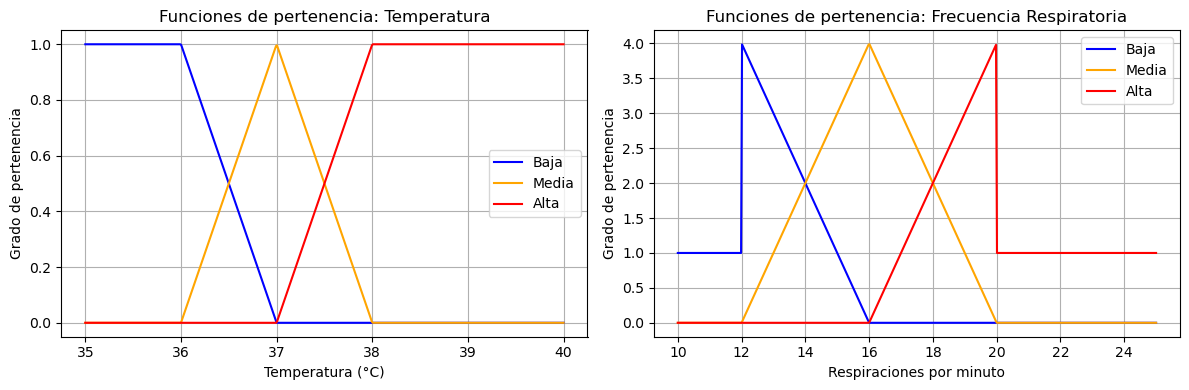

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de valores para temperatura y frecuencia respiratoria
x_temp = np.linspace(35, 40, 500)
x_resp = np.linspace(10, 25, 500)

# Aplicar funciones de pertenencia para cada punto
y_temp_baja = [baja_temp(x) for x in x_temp]
y_temp_media = [media_temp(x) for x in x_temp]
y_temp_alta = [alta_temp(x) for x in x_temp]

y_resp_baja = [baja_resp(x) for x in x_resp]
y_resp_media = [media_resp(x) for x in x_resp]
y_resp_alta = [alta_resp(x) for x in x_resp]

# Crear figura
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Temperatura
axs[0].plot(x_temp, y_temp_baja, label='Baja', color='blue')
axs[0].plot(x_temp, y_temp_media, label='Media', color='orange')
axs[0].plot(x_temp, y_temp_alta, label='Alta', color='red')
axs[0].set_title('Funciones de pertenencia: Temperatura')
axs[0].set_xlabel('Temperatura (°C)')
axs[0].set_ylabel('Grado de pertenencia')
axs[0].legend()
axs[0].grid(True)

# Frecuencia respiratoria
axs[1].plot(x_resp, y_resp_baja, label='Baja', color='blue')
axs[1].plot(x_resp, y_resp_media, label='Media', color='orange')
axs[1].plot(x_resp, y_resp_alta, label='Alta', color='red')
axs[1].set_title('Funciones de pertenencia: Frecuencia Respiratoria')
axs[1].set_xlabel('Respiraciones por minuto')
axs[1].set_ylabel('Grado de pertenencia')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


## Visualización de la salida del sistema difuso

La gráfica 3D muestra cómo varía el **índice de riesgo** (entre 0 y 1) en función de:

- **Temperatura corporal** (eje X)
- **Frecuencia respiratoria** (eje Y)

### Interpretación de la superficie

- En la región inferior izquierda (baja temperatura y baja respiración), el riesgo es **bajo**.
- En el centro (valores medios), el riesgo es **moderado**.
- En la región superior derecha (alta temperatura y alta frecuencia respiratoria), el riesgo se vuelve **alto**.

Esta visualización confirma que el sistema difuso combina suavemente las entradas, generando una transición continua entre diferentes niveles de riesgo, en lugar de saltos bruscos como en la lógica clásica.



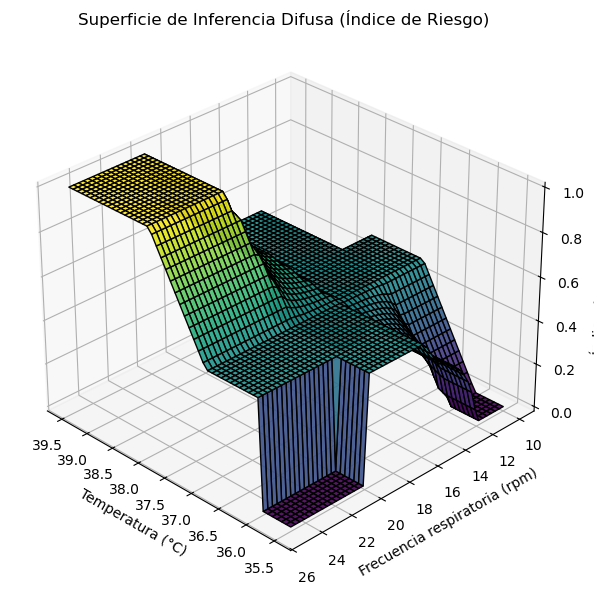

In [64]:
from mpl_toolkits.mplot3d import Axes3D

# Crear una malla de valores de temperatura y respiración
temp_vals = np.linspace(35.5, 39.5, 50)
resp_vals = np.linspace(10, 25, 50)
T, R = np.meshgrid(temp_vals, resp_vals)

# Calcular riesgo para cada punto de la malla
Z = np.array([[motor_inferencia_difusa(t, r) for t in temp_vals] for r in resp_vals])

# Crear figura 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Dibujar superficie
ax.plot_surface(T, R, Z, cmap='viridis', edgecolor='k', alpha=0.9)

# Etiquetas
ax.set_title('Superficie de Inferencia Difusa (Índice de Riesgo)')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Frecuencia respiratoria (rpm)')
ax.set_zlabel('Índice de riesgo')
ax.view_init(elev=30, azim=135)  # Ángulo de vista

plt.tight_layout()
plt.show()
